# **--- GETAROUND PROJECT (pricing optimization) EDA ---** #

## **1. Libraries import** ##

In [37]:
import pandas as pd
import numpy as np
import os
import json


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy.stats.mstats import winsorize
from scipy.stats import chi2_contingency

## **2. Data import and first observations** ##

In [38]:
raw_df_pricing=pd.read_csv("../DATA/Data_raw/get_around_pricing_project.csv")
raw_df_pricing.head()

,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


In [39]:
raw_df_pricing.shape

(4843, 15)

In [40]:
raw_df_pricing.info() # => No missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Unnamed: 0                 4843 non-null   int64 
 1   model_key                  4843 non-null   object
 2   mileage                    4843 non-null   int64 
 3   engine_power               4843 non-null   int64 
 4   fuel                       4843 non-null   object
 5   paint_color                4843 non-null   object
 6   car_type                   4843 non-null   object
 7   private_parking_available  4843 non-null   bool  
 8   has_gps                    4843 non-null   bool  
 9   has_air_conditioning       4843 non-null   bool  
 10  automatic_car              4843 non-null   bool  
 11  has_getaround_connect      4843 non-null   bool  
 12  has_speed_regulator        4843 non-null   bool  
 13  winter_tires               4843 non-null   bool  
 14  rental_p

In [41]:
raw_df_pricing.describe(include="all")

,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
count,4843.000000,4843,4.843000e+03,4843.00000,4843,4843,4843,4843,4843,4843,4843,4843,4843,4843,4843.000000
unique,NaN,28,NaN,NaN,4,10,8,2,2,2,2,2,2,2,NaN
top,NaN,Citroën,NaN,NaN,diesel,black,estate,True,True,False,False,False,False,True,NaN
freq,NaN,969,NaN,NaN,4641,1633,1606,2662,3839,3865,3881,2613,3674,4514,NaN
mean,2421.000000,NaN,1.409628e+05,128.98823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.214536
std,1398.198007,NaN,6.019674e+04,38.99336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.568268
min,0.000000,NaN,-6.400000e+01,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000
25%,1210.500000,NaN,1.029135e+05,100.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104.000000
50%,2421.000000,NaN,1.410800e+05,120.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119.000000
75%,3631.500000,NaN,1.751955e+05,135.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.000000


In [42]:
# Delete useless column
raw_df_pricing=raw_df_pricing.drop(columns="Unnamed: 0").copy()

In [43]:
# Check for duplicates
raw_df_pricing.duplicated().sum() # => No duplicates

0

## **3. Data exploration analysis** ##

### **1. Preparing variable for analysis** ###

In [44]:
# Separating the variables per type :
raw_num_col=raw_df_pricing.select_dtypes(include=["int64"]).copy()
raw_cat_col=raw_df_pricing.select_dtypes(include="object").copy()
raw_bool_col=raw_df_pricing.select_dtypes(include="bool").copy()

# Lists of column names : 
num_col_names=raw_num_col.columns.to_list()
cat_col_names=raw_cat_col.columns.to_list()
bool_col_names=raw_bool_col.columns.to_list()

### **2. Target distribution** ###

In [45]:
target="rental_price_per_day"

<Axes: xlabel='rental_price_per_day', ylabel='Count'>

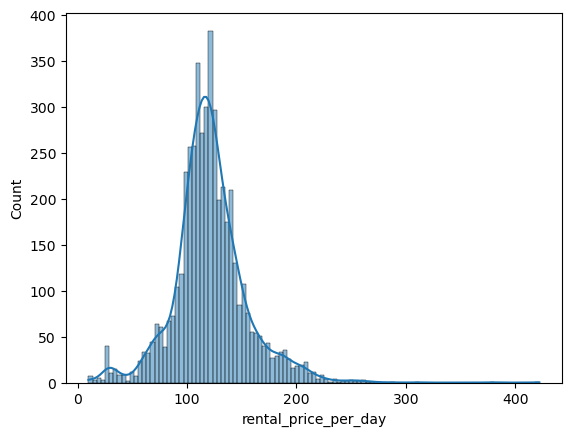

In [46]:
sns.histplot(raw_df_pricing[target], kde=True)

In [47]:
fig=px.scatter(data_frame=raw_df_pricing[target],width=800,height=400,title="Target variable")
fig.show()

### **3. Outliers analysis** ###

_**0. Analysis for the target variable (numerical)**_

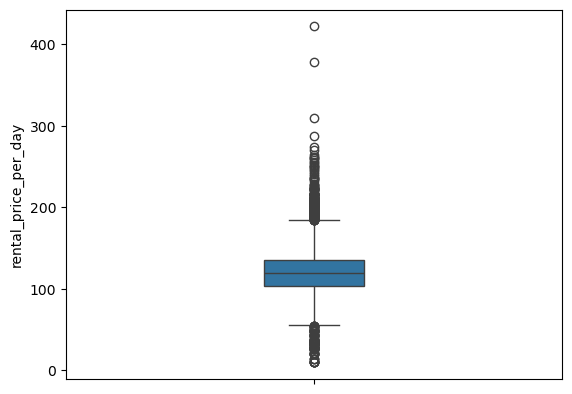

In [48]:
# Check for anomalies with a boxplot

sns.boxplot(y=raw_df_pricing[target],width=0.2)
plt.show()


In [49]:
# We calculate Quartiles and IQR
Q1=raw_df_pricing[target].quantile(0.25)
Q3=raw_df_pricing[target].quantile(0.75)
IQR=Q3-Q1

# We define outliers boundaries
lower_bound=Q1 - 1.5 * IQR # (The factor 1.5 is the standard threshold for mild outliers)
upper_bound=Q3 + 1.5 * IQR

# We identify the outliers
outlier_mask=(raw_df_pricing[target]<lower_bound) | (raw_df_pricing[target]>upper_bound)
outliers_rows=raw_df_pricing[target][outlier_mask]
display(outliers_rows.sort_values(ascending=False))
print("Lower boundary :",lower_bound)
print("Upper boundary :",upper_bound)

4753    422
4684    378
90      309
4146    287
2938    274
       ... 
1255     10
1832     10
630      10
4356     10
879      10
Name: rental_price_per_day, Length: 345, dtype: int64

Lower boundary : 56.0
Upper boundary : 184.0


It look's that we have really high prices for some rentals, it might be outliers or real value (for instance for the rental of "luxarious" cars). We are going to keep them and to see the influence of these values on our model.

_**1. Analysis for numerical features**_

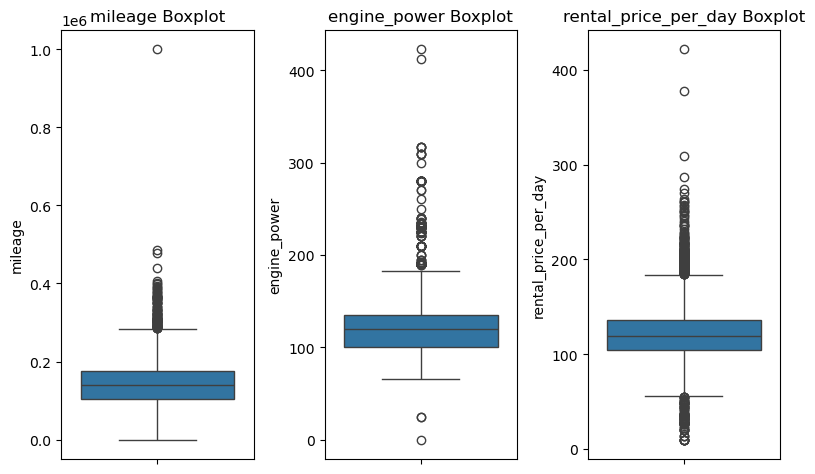

In [50]:
# Check for anomalies with a boxplot

fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(8,5))

for i,num_col in enumerate(num_col_names):
    sns.boxplot(raw_df_pricing,y=num_col,ax=ax[i])
    ax[i].set_title(f"{num_col} Boxplot")

plt.tight_layout() # Prevent the overlapping of the layout
plt.show()

We can observe the presence of ouliers on the boxplots, let's observe the corresponding rows to check if they are possible rare values or real errors. To do so, we use the IQR (Interquartile Range) method, which is more robust to extrem values.

In [51]:
bound_dict={}
for num_col in num_col_names:

    # We calculate Quartiles and IQR
    Q1=raw_df_pricing[num_col].quantile(0.25)
    Q3=raw_df_pricing[num_col].quantile(0.75)
    IQR=Q3-Q1

    # We define outliers boundaries
    lower_bound=Q1 - 1.5 * IQR # (The factor 1.5 is the standard threshold for mild outliers)
    upper_bound=Q3 + 1.5 * IQR

    # We identify the outliers
    outlier_mask=(raw_df_pricing[num_col]<lower_bound) | (raw_df_pricing[num_col]>upper_bound)
    outliers_rows=raw_df_pricing[outlier_mask]
    print (f"---- Boundaries for '{num_col}' ----")
    print("Lower boundary :",lower_bound)
    print("Upper boundary :",upper_bound,"\n")
    if num_col not in bound_dict.keys():
        bound_dict[num_col]=(lower_bound,upper_bound)

print("Outliers row : ")
display(outliers_rows.sort_values(num_col,ascending=False).head())

---- Boundaries for 'mileage' ----
Lower boundary : -5509.5
Upper boundary : 283618.5 

---- Boundaries for 'engine_power' ----
Lower boundary : 47.5
Upper boundary : 187.5 

---- Boundaries for 'rental_price_per_day' ----
Lower boundary : 56.0
Upper boundary : 184.0 

Outliers row : 


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
4753,BMW,72515,135,diesel,blue,suv,False,False,True,False,False,False,False,422
4684,SEAT,103222,140,diesel,grey,suv,True,True,False,False,True,False,True,378
90,Renault,12402,170,hybrid_petrol,grey,coupe,True,True,False,False,False,False,False,309
4146,Suzuki,2970,423,petrol,red,suv,True,True,True,False,False,False,True,287
2938,Renault,-64,230,diesel,black,sedan,True,True,False,True,False,False,True,274


We need to check if these mileages are possible for cars according to their brands, indeed, they do not all have the same maximum mileage. In order to do so, we are going to use the probability for a mileage to be >= 250,000 miles given by [iSeeCars](https://www.iseecars.com/longest-lasting-car-brands-study?utm_source=chatgpt.com) website.

In [52]:
# List of brands : 
brands=sorted(raw_df_pricing['model_key'].unique().tolist())
print(brands)

['Alfa Romeo', 'Audi', 'BMW', 'Citroën', 'Ferrari', 'Fiat', 'Ford', 'Honda', 'KIA Motors', 'Lamborghini', 'Lexus', 'Maserati', 'Mazda', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan', 'Opel', 'PGO', 'Peugeot', 'Porsche', 'Renault', 'SEAT', 'Subaru', 'Suzuki', 'Toyota', 'Volkswagen', 'Yamaha']


In [53]:
# Dictinary created wih data from iSeeCars website
brand_mileage={
  'Alfa Romeo': None,
  'Audi': 0.3,
  'BMW': 0.4,
  'Citroën': None,
  'Ferrari': None,
  'Fiat': None,
  'Ford': 3.1,
  'Honda': 10.8,
  'KIA Motors': 0.6,
  'Lamborghini': None,
  'Lexus': 12.8,
  'Maserati': 0.0,
  'Mazda': 3.6,
  'Mercedes': 1.7,
  'Mini': 0.0,
  'Mitsubishi': 1.1,
  'Nissan': 2.4,
  'Opel': None,
  'PGO': None,
  'Peugeot': None,
  'Porsche': 0.5,
  'Renault': None,
  'SEAT': None,
  'Subaru': 2.3,
  'Suzuki': None,
  'Toyota': 17.8,
  'Volkswagen': 0.4,
  'Yamaha': None
}


In [54]:
brand_mileage_df=pd.DataFrame({"Brand":list(brand_mileage.keys()),"Probabililty (%)":list(brand_mileage.values())}).sort_values(by="Probabililty (%)",ascending=False)
brand_mileage_df

,Brand,Probabililty (%)
25,Toyota,17.8
10,Lexus,12.8
7,Honda,10.8
12,Mazda,3.6
6,Ford,3.1
16,Nissan,2.4
23,Subaru,2.3
13,Mercedes,1.7
15,Mitsubishi,1.1
8,KIA Motors,0.6


This table gives us the probability for a car of a given brand to have a mileage higher than 250,000 miles. We can withdraw all the brands that have a probability lower than 3%.

In [55]:
# We create a list of brands with a probability lower than 3% and not NaN.
brand_low_proba_mileage=brand_mileage_df.loc[brand_mileage_df["Probabililty (%)"].notna() & (brand_mileage_df["Probabililty (%)"]<3),"Brand"].tolist()
brand_low_proba_mileage

['Nissan',
 'Subaru',
 'Mercedes',
 'Mitsubishi',
 'KIA Motors',
 'Porsche',
 'BMW',
 'Volkswagen',
 'Audi',
 'Maserati',
 'Mini']

Some cars can have higher mileage than other but we can now delete the rows concerning the brands we have just selected where the mileage is upper than the upper boudary defined earlier.

In [56]:
mask=raw_df_pricing["mileage"]>bound_dict["mileage"][1]
raw_df_pricing=raw_df_pricing[~mask]
raw_df_pricing.shape

(4746, 14)

Now let's remove all the rows with an engine power corresponding to an outlier:

In [57]:
mask=(raw_df_pricing["engine_power"]<bound_dict["engine_power"][0]) |\
(raw_df_pricing["engine_power"]>bound_dict["engine_power"][1])
print("Pourcentage of outliers linked to the engine power: ", round(raw_df_pricing[mask].shape[0]/raw_df_pricing.shape[0]*100,2))

Pourcentage of outliers linked to the engine power:  12.31


Some cars are way more powerfull than other according to the brands and the models. As we don't have enough informations about the models of the cars, we can winsorized the data instead of deleting all the outliers. 

In [58]:
raw_df_pricing["engine_power"]=winsorize(raw_df_pricing["engine_power"],limits=[0.05,0.05])

_**2. Analysis of frequencies for categorical and boolean features**_

For categorical and boolean features, we are going to check if we have rare categories and an imbalanced distribution in order to identify outliers.

'model_key' distribution
model_key
Citroën        0.198062
Renault        0.188580
BMW            0.174041
Peugeot        0.132743
Audi           0.107670
Nissan         0.057522
Mitsubishi     0.047408
Mercedes       0.020438
Volkswagen     0.012642
Toyota         0.011167
SEAT           0.009692
Subaru         0.008639
Opel           0.006953
PGO            0.006953
Ferrari        0.006532
Maserati       0.003582
Suzuki         0.001686
Porsche        0.001264
Ford           0.001054
KIA Motors     0.000632
Alfa Romeo     0.000632
Fiat           0.000421
Lexus          0.000421
Lamborghini    0.000421
Mini           0.000211
Mazda          0.000211
Honda          0.000211
Yamaha         0.000211
Name: proportion, dtype: float64 

'fuel' distribution
fuel
diesel           0.958913
petrol           0.038769
hybrid_petrol    0.001686
electro          0.000632
Name: proportion, dtype: float64 

'paint_color' distribution
paint_color
black     0.337337
grey      0.241888
blue      0.14538

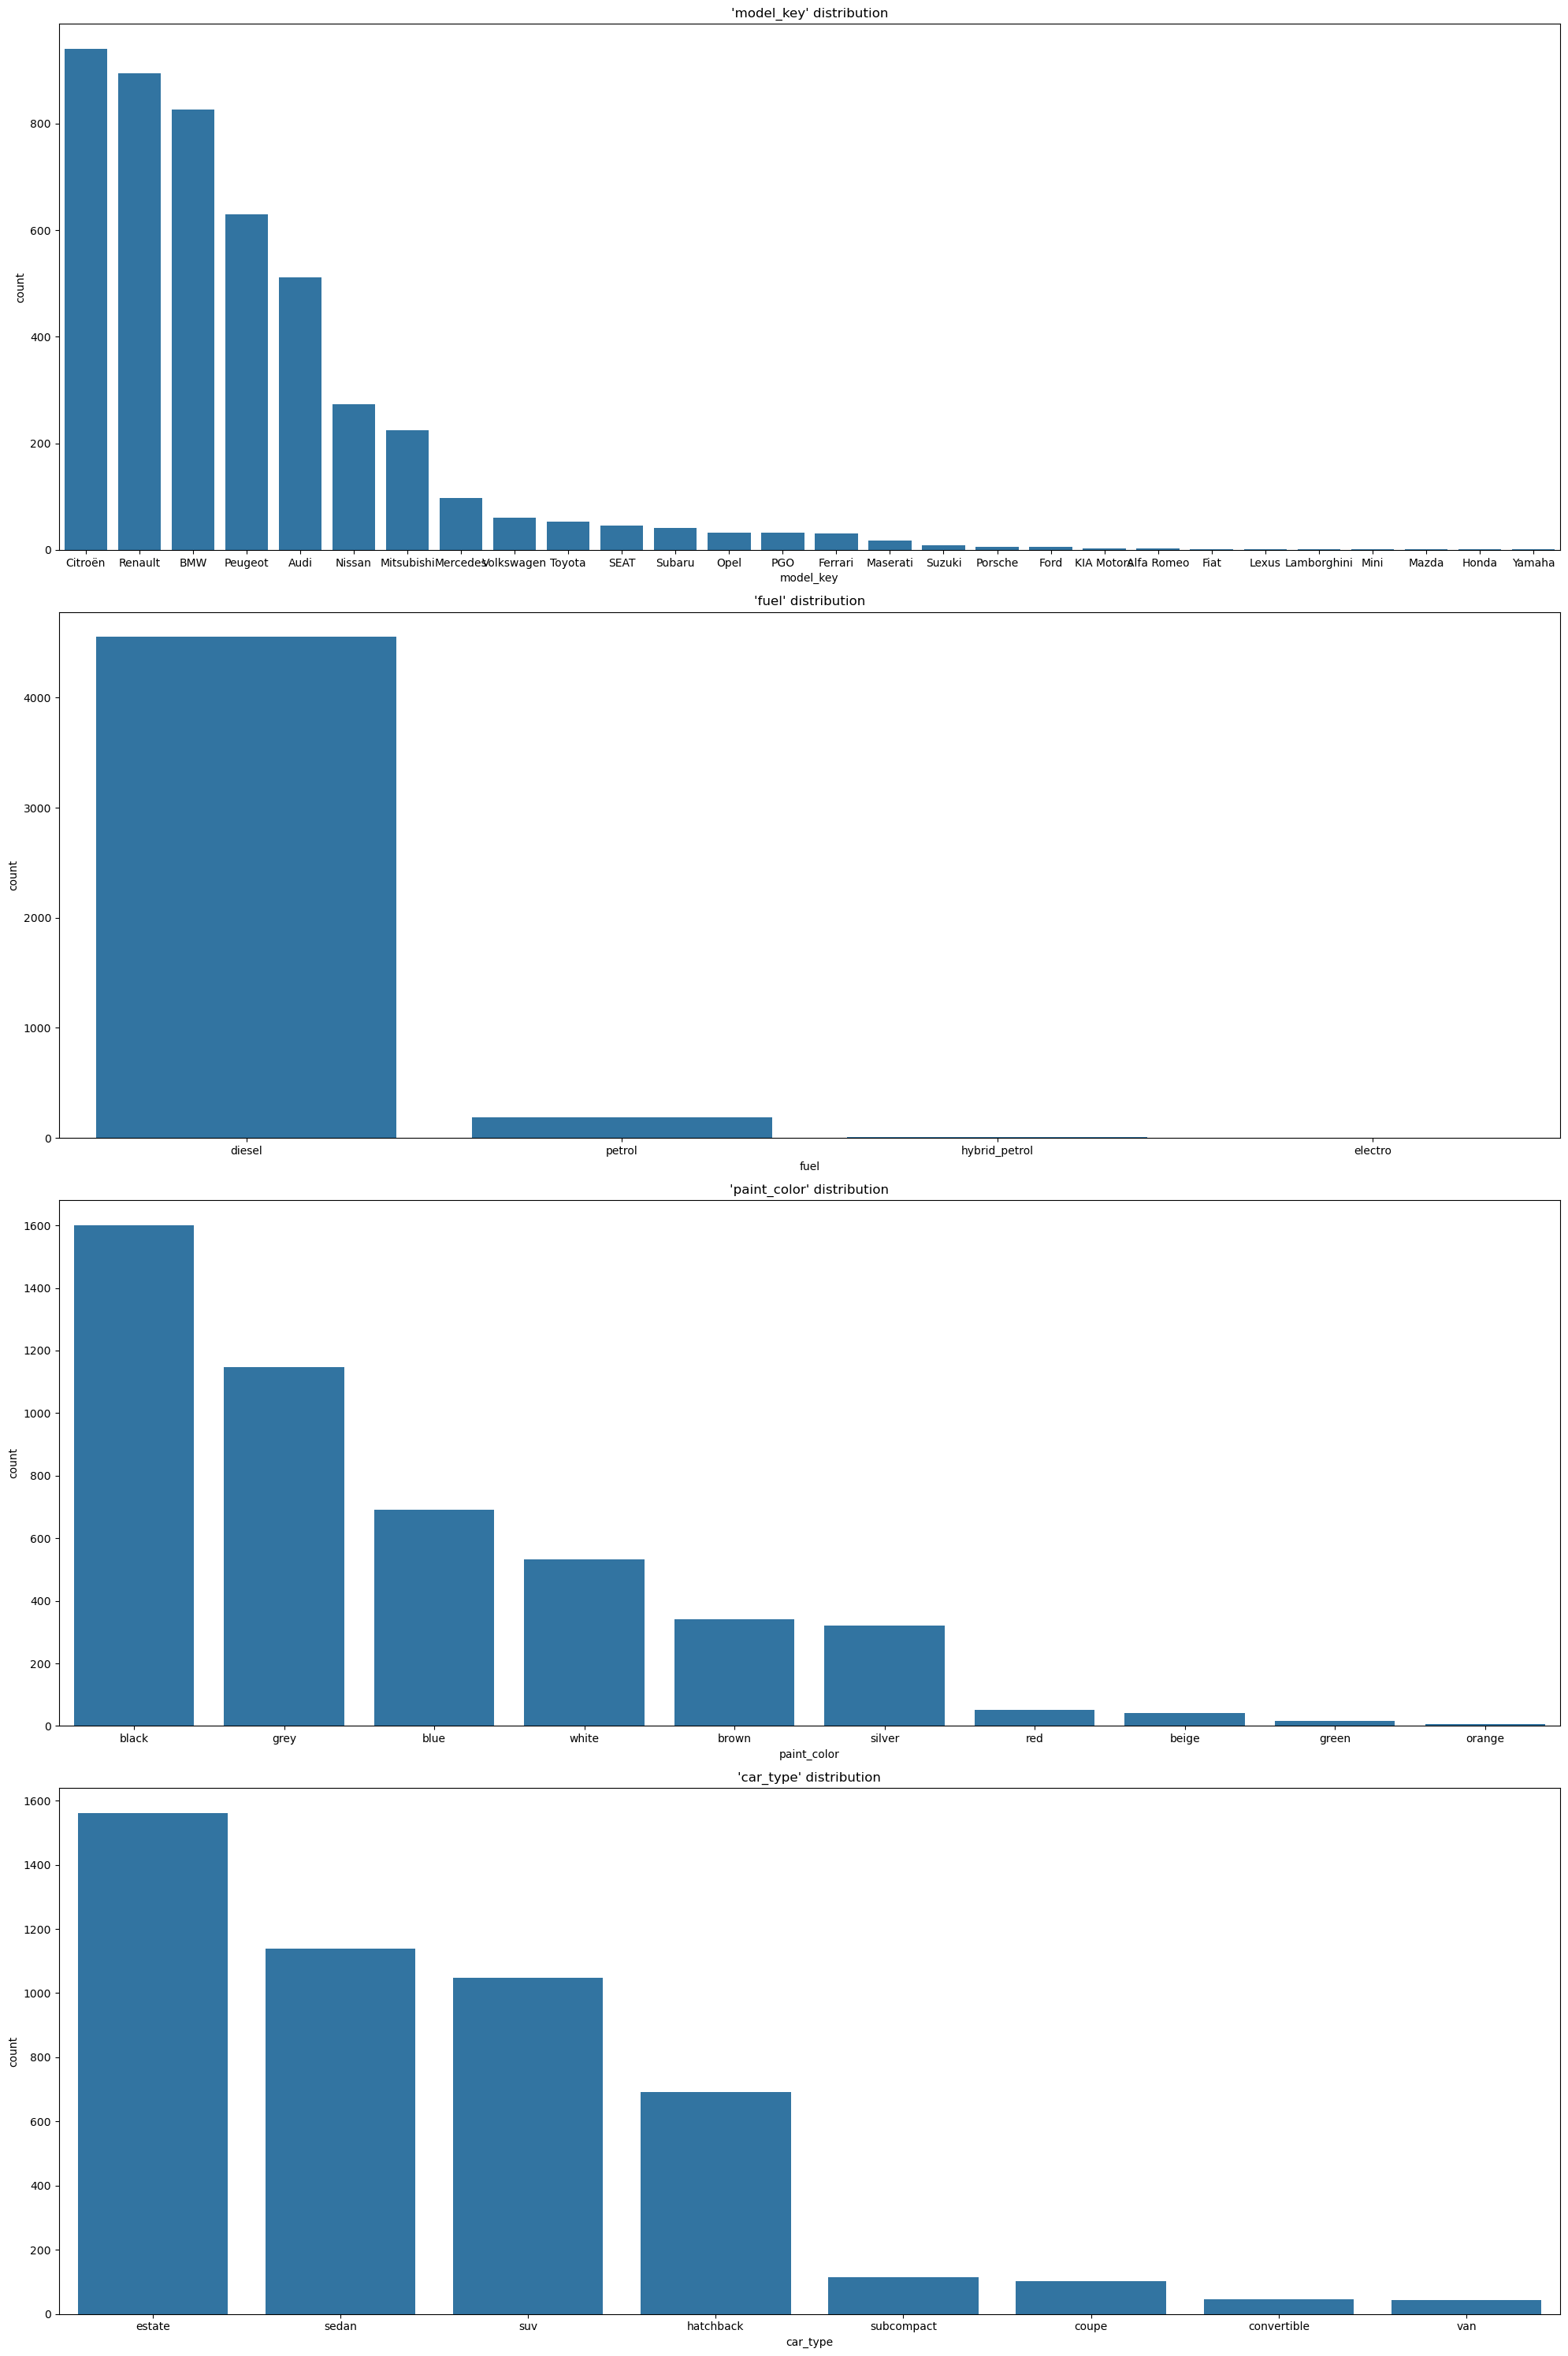

In [59]:
fig,ax=plt.subplots(nrows=len(cat_col_names),ncols=1,figsize=(20,30))

for i,cat_col in enumerate(cat_col_names):
    print(f"'{cat_col}' distribution")
    print(raw_df_pricing[cat_col].value_counts(normalize=True),"\n")
    sns.countplot(data=raw_df_pricing,x=cat_col,ax=ax[i],order=raw_df_pricing[cat_col].value_counts().index)
    ax[i].set_title(f"'{cat_col}' distribution")

plt.tight_layout() 
plt.show()

We can observe an uneven distribution of the categorical features. Some categories are under-represented. We define a rarity threshold of 1% and we group the rare classes together as "other". (We don't delete them as they do not look like errors but rather rare classes).

In [60]:
threshold=0.01
for cat_col in cat_col_names:
    freq=raw_df_pricing[cat_col].value_counts(normalize=True)
    rare_cat=freq[freq.round(4)<threshold].index.tolist()

    if rare_cat:
        raw_df_pricing[cat_col] = raw_df_pricing[cat_col].replace(rare_cat, "Other")
        print(f"Categorical feature '{cat_col}': replaced rare categories {rare_cat}")
    else:
        print(f"Categorical feature '{cat_col}': no rare categories")

Categorical feature 'model_key': replaced rare categories ['SEAT', 'Subaru', 'Opel', 'PGO', 'Ferrari', 'Maserati', 'Suzuki', 'Porsche', 'Ford', 'KIA Motors', 'Alfa Romeo', 'Fiat', 'Lexus', 'Lamborghini', 'Mini', 'Mazda', 'Honda', 'Yamaha']
Categorical feature 'fuel': replaced rare categories ['hybrid_petrol', 'electro']
Categorical feature 'paint_color': replaced rare categories ['beige', 'green', 'orange']
Categorical feature 'car_type': replaced rare categories ['convertible', 'van']


In [61]:
mask[raw_df_pricing["paint_color"]=="Other"]
raw_df_pricing[mask]

,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
1,Citroën,13929,210,petrol,grey,Other,True,True,False,False,False,True,True,264
5,Citroën,152352,210,petrol,black,Other,True,True,False,False,True,True,True,131
17,Peugeot,24521,210,petrol,grey,Other,True,False,False,False,False,False,True,96
20,Peugeot,126213,210,petrol,white,Other,False,False,False,False,False,True,True,130
26,Peugeot,113678,190,diesel,black,Other,True,True,False,False,True,True,True,173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4793,Toyota,125197,210,diesel,blue,suv,True,True,True,True,True,True,True,207
4795,Mitsubishi,87745,210,diesel,brown,suv,True,True,True,True,False,True,True,211
4796,Mitsubishi,111962,190,diesel,black,suv,True,True,False,False,True,False,True,163
4797,Mitsubishi,122949,190,diesel,brown,suv,True,True,True,True,False,True,True,194


Let's now observe the distribution of the boolean features :

'private_parking_available' distribution
private_parking_available
True     0.546566
False    0.453434
Name: proportion, dtype: float64 

'has_gps' distribution
has_gps
True     0.797303
False    0.202697
Name: proportion, dtype: float64 

'has_air_conditioning' distribution
has_air_conditioning
False    0.799621
True     0.200379
Name: proportion, dtype: float64 

'automatic_car' distribution
automatic_car
False    0.798778
True     0.201222
Name: proportion, dtype: float64 

'has_getaround_connect' distribution
has_getaround_connect
False    0.53898
True     0.46102
Name: proportion, dtype: float64 

'has_speed_regulator' distribution
has_speed_regulator
False    0.755794
True     0.244206
Name: proportion, dtype: float64 

'winter_tires' distribution
winter_tires
True     0.930889
False    0.069111
Name: proportion, dtype: float64 



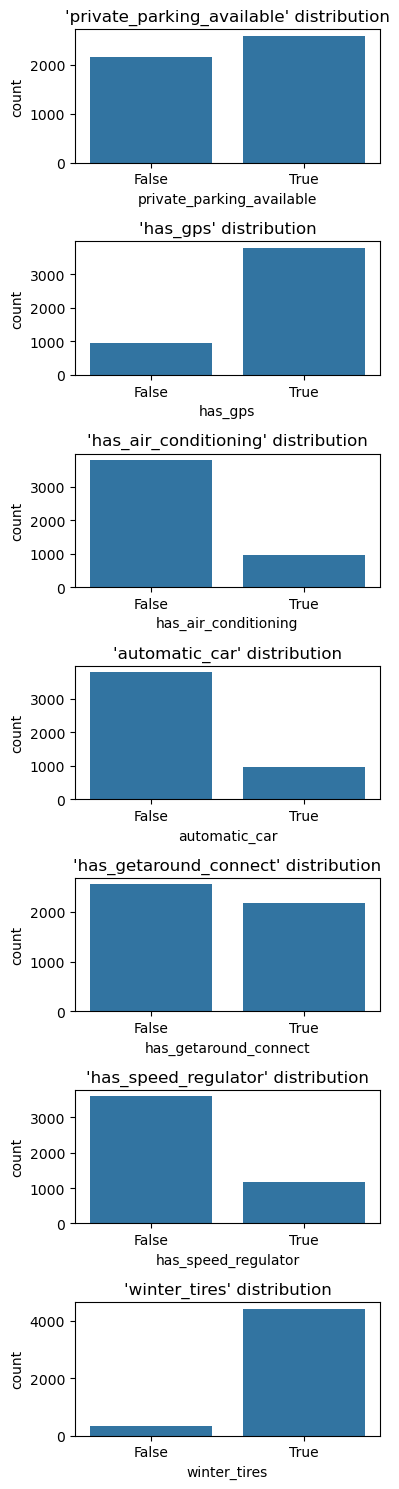

In [62]:
fig,ax=plt.subplots(nrows=len(bool_col_names),ncols=1,figsize=(4,15))

for i,bool_col in enumerate(bool_col_names):
    print(f"'{bool_col}' distribution")
    print(raw_df_pricing[bool_col].value_counts(normalize=True),"\n")
    sns.countplot(data=raw_df_pricing,x=bool_col,ax=ax[i])
    ax[i].set_title(f"'{bool_col}' distribution")

plt.tight_layout() 
plt.show()

For boolean features, the imbalance is less problematic than for a target variable so we don't need to delete data. Moreover, tree-based models handle imbalance automatically.

### **4. Univariate analysis** ###

_**1. Analysis of numerical variables**_

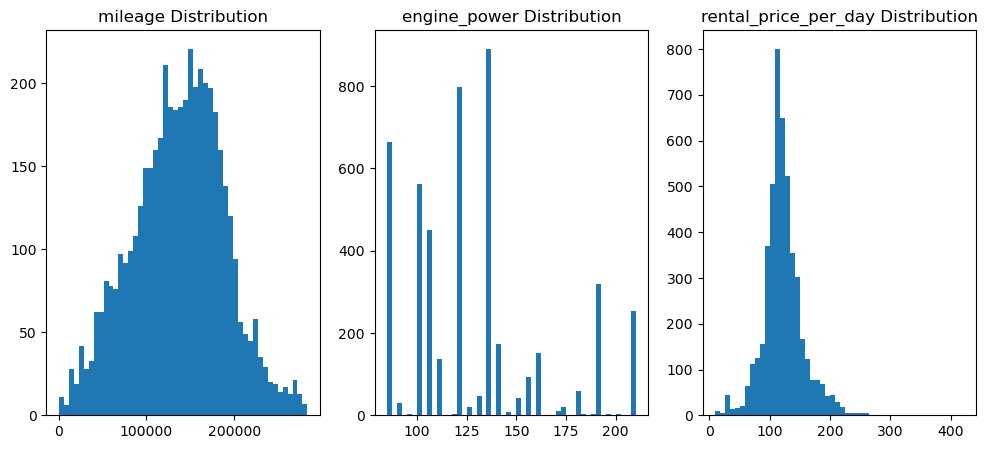

In [63]:
fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(12,5))

for i,num_col in enumerate(num_col_names):

    ax[i].hist(raw_df_pricing[num_col],bins=50)
    ax[i].set_title(f"{num_col} Distribution")


_**2. Analysis of categorical variables**_

'model_key' distribution
model_key
Citroën       0.198062
Renault       0.188580
BMW           0.174041
Peugeot       0.132743
Audi          0.107670
Nissan        0.057522
Other         0.049726
Mitsubishi    0.047408
Mercedes      0.020438
Volkswagen    0.012642
Toyota        0.011167
Name: proportion, dtype: float64 

'fuel' distribution
fuel
diesel    0.958913
petrol    0.038769
Other     0.002318
Name: proportion, dtype: float64 

'paint_color' distribution
paint_color
black     0.337337
grey      0.241888
blue      0.145386
white     0.112094
brown     0.071639
silver    0.067425
Other     0.013274
red       0.010957
Name: proportion, dtype: float64 

'car_type' distribution
car_type
estate        0.328909
sedan         0.239992
suv           0.220607
hatchback     0.145596
subcompact    0.024231
coupe         0.021492
Other         0.019174
Name: proportion, dtype: float64 



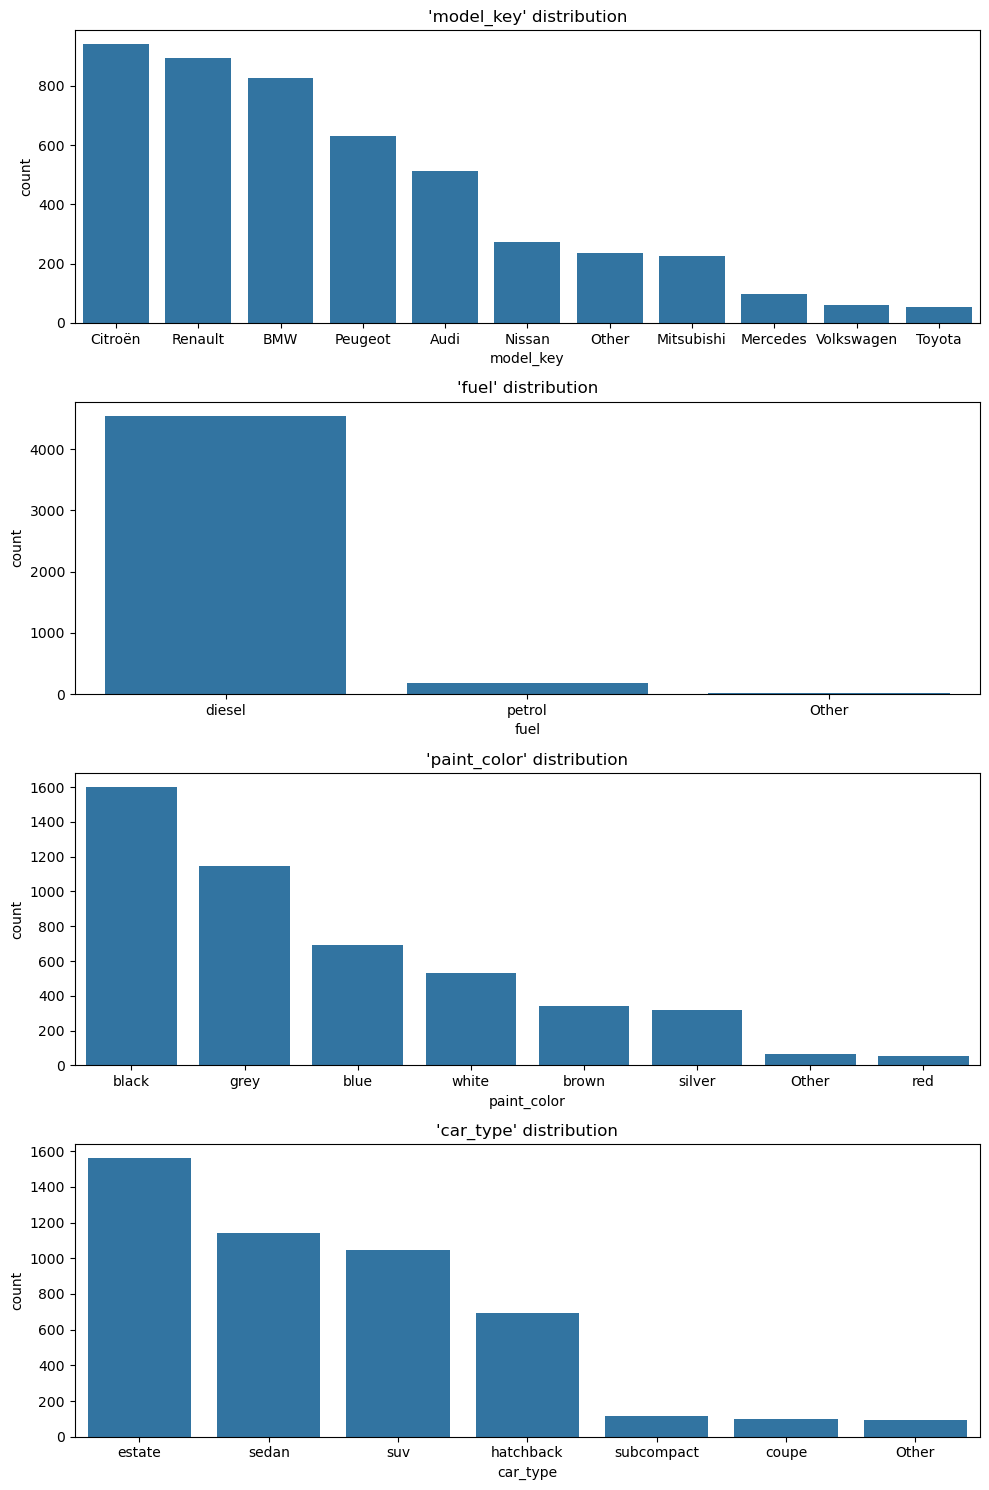

In [64]:
fig,ax=plt.subplots(nrows=len(cat_col_names),ncols=1,figsize=(10,15))

for i,cat_col in enumerate(cat_col_names):
    print(f"'{cat_col}' distribution")
    print(raw_df_pricing[cat_col].value_counts(normalize=True),"\n")
    sns.countplot(data=raw_df_pricing,x=cat_col,ax=ax[i],order=raw_df_pricing[cat_col].value_counts().index)
    ax[i].set_title(f"'{cat_col}' distribution")

plt.tight_layout() 
plt.show()

### **5. Multivariate analysis** ###

_**1. Relationship between predictors**_

_a - Numerical vs numerical features_

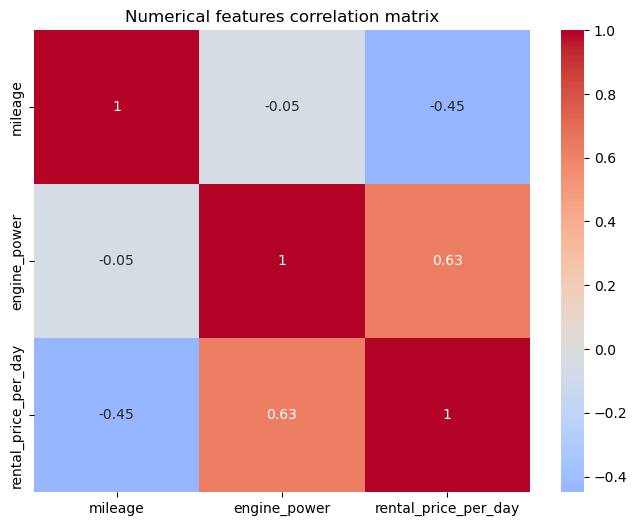

In [65]:
corr_matrix =raw_num_col.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True)
plt.title("Numerical features correlation matrix")
plt.show()

It seems that there is strong positively correlation between the rental price per day and the engine power and a weaker negative correlation with the mileage.

_b - Categorical & booleans vs categorical features_

We try to understand wheather categorical/boolean variables are dependent or redundant. for this, we are using association tests.

In [66]:
# We build contingency tables

cat_bool_cols = ['fuel', 'paint_color', 'car_type', 'model_key',
                 'private_parking_available', 'has_gps', 'has_air_conditioning',
                 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']

results = []
for i, col1 in enumerate(cat_bool_cols):
    for col2 in cat_bool_cols[i+1:]:
        ct = pd.crosstab(raw_df_pricing[col1], raw_df_pricing[col2])
        chi2, p, _, _ = chi2_contingency(ct)
        results.append({"Feature 1": col1, "Feature 2": col2, "p-value": round(p, 4)})

ct_df = pd.DataFrame(results).sort_values("p-value")
display(ct_df[ct_df["p-value"] < 0.05].head(10))  # affiche les paires dépendantes


,Feature 1,Feature 2,p-value
27,model_key,private_parking_available,0.0
29,model_key,has_air_conditioning,0.0
30,model_key,automatic_car,0.0
31,model_key,has_getaround_connect,0.0
32,model_key,has_speed_regulator,0.0
33,model_key,winter_tires,0.0
34,private_parking_available,has_gps,0.0
35,private_parking_available,has_air_conditioning,0.0
36,private_parking_available,automatic_car,0.0
37,private_parking_available,has_getaround_connect,0.0


The p-value is very small so it was rounded to 0.

_**2. Relationship with the target**_

_a - Numerical features vs target_

In [32]:
raw_num_col.columns.tolist()

['mileage', 'engine_power', 'rental_price_per_day']

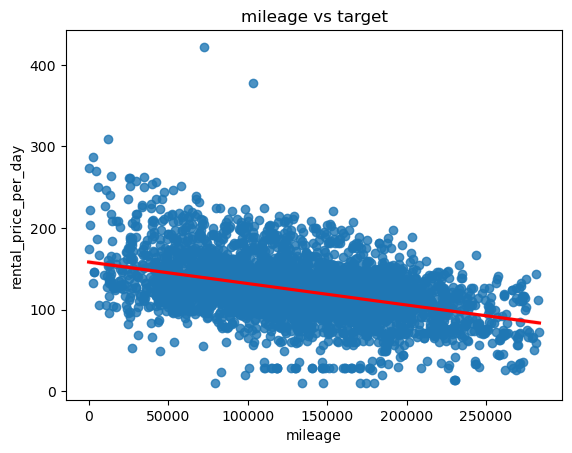

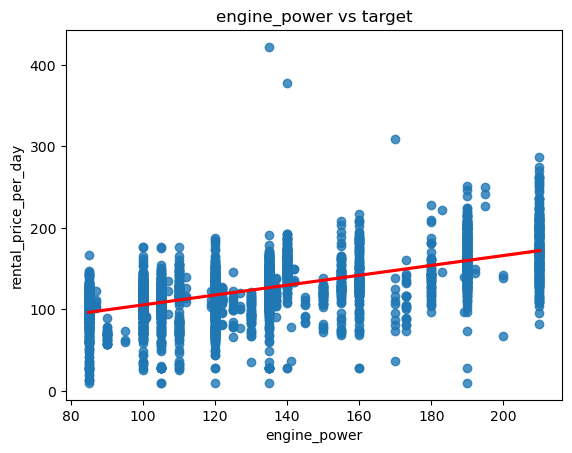

In [33]:
for num_col in ['mileage', 'engine_power']:
    sns.regplot(x=raw_df_pricing[num_col], y=raw_df_pricing[target], fit_reg=True,line_kws={"color": "red"})
    plt.title(f"{num_col} vs target")
    plt.show()

It seems that : 
- the lower the mileage and the higher the renting price,
- The higher the engine power of the car, the higher the renting price. 

_b - Categorical features vs target_

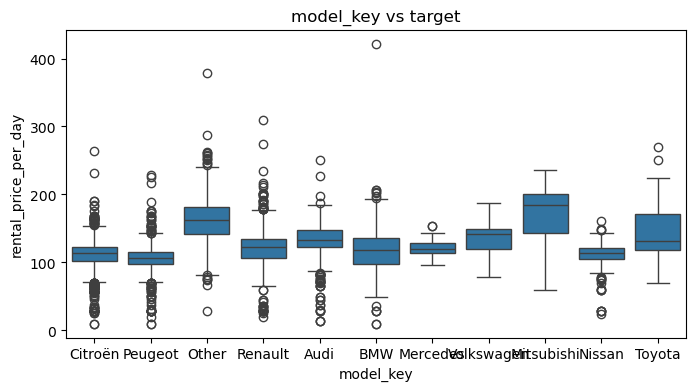

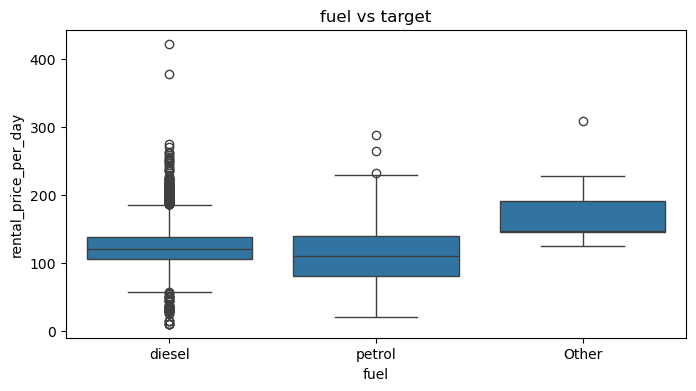

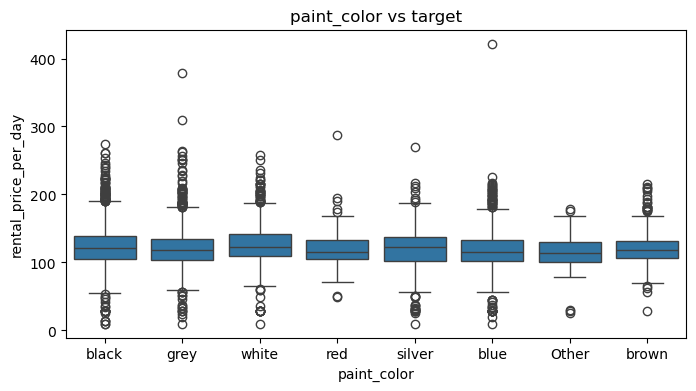

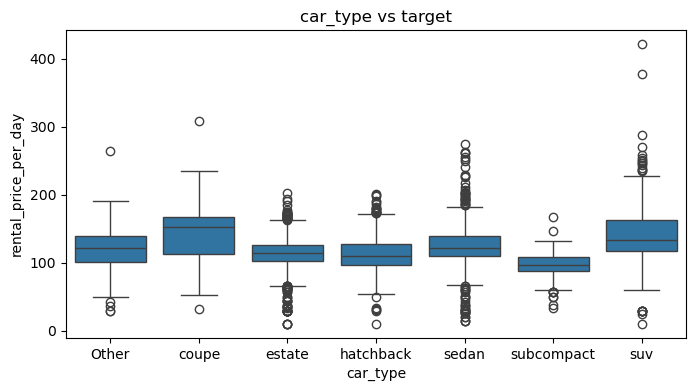

In [34]:
for cat_col in raw_cat_col:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=raw_df_pricing[cat_col], y=raw_df_pricing[target])
    plt.title(f"{cat_col} vs target")
    plt.show()

_c - Boolean features vs target_

In [ ]:
from scipy.stats import ttest_ind

ttest_results = {}

for bool_col in raw_bool_col:

    # valeurs uniques (0/1 ou True/False)
    unique_vals = raw_df_pricing[bool_col].dropna().unique()
    if len(unique_vals) != 2:
        continue

    # On extrait uniquement la target !
    group0 = raw_df_pricing[raw_df_pricing[bool_col] == unique_vals[0]][target]
    group1 = raw_df_pricing[raw_df_pricing[bool_col] == unique_vals[1]][target]

    # Test t
    stat, p = ttest_ind(group0, group1, equal_var=False)

    ttest_results[bool_col] = {
        "t_stat": stat,
        "p_value": p,
        "mean_group0": group0.mean(),
        "mean_group1": group1.mean()
    }

pd.DataFrame(ttest_results).T


,t_stat,p_value,mean_group0,mean_group1
private_parking_available,21.471998,1.127918e-97,130.901696,111.612918
has_gps,20.068552,4.953317e-79,126.975687,103.195426
has_air_conditioning,-15.338385,8.502982e-49,118.043215,138.565720
automatic_car,-28.979085,2.449124e-143,115.212609,149.716230
has_getaround_connect,23.434279,5.322802e-115,133.454753,112.490618
has_speed_regulator,15.730934,1.631335e-52,135.267472,117.918874
winter_tires,1.312349,1.902514e-01,122.375057,119.198171


The three factors that seems to have the more influence on the price are : 
- whether the car is automatic or not,
- whether the car has a getaround connection or not,
- whether a private parking is available. 
But there is no relation between the rental price and the presence of winter tires.

## **4. Data export** ##

In [ ]:
raw_df_pricing.to_csv('../DATA/Data_intermediate/df_pricing_clean.csv', index=False) 